# Using spOT-NMF as a factorization backend in mosaicMPI

[mosaicMPI](https://github.com/MorrissyLab/mosaicMPI) is a framework for
**consensus matrix factorization, rank (k) selection, and multi-dataset
integration** of omics data. Out of the box it factorizes with consensus NMF
(cNMF, scikit-learn NMF under the hood).

`spOT-NMF` implements an **optimal-transport NMF (OT-NMF)** that accounts for
gene–gene relationships through a ground cost. This tutorial shows how to plug
spOT-NMF in as mosaicMPI's factorization engine, so that a single spOT-NMF
solve becomes one replicate inside mosaicMPI's consensus pipeline. You then get
everything mosaicMPI provides — replicate consensus, a stability/error rank
selection curve, program-usage heatmaps, and cross-dataset integration — driven
by OT-NMF instead of vanilla NMF.

The only change versus a standard mosaicMPI run is a single argument:
`initialize_cnmf(..., algorithm="spotnmf")`.

**Requirements:** `pip install spot-nmf mosaicmpi` (spOT-NMF needs
[PyTorch](https://pytorch.org); the usage heatmap in step 7 needs
`PyComplexHeatmap`). Importing this notebook's cells registers the `spotnmf`
backend with mosaicMPI automatically.

> This is a downsized demo (a subsample of a public Visium slide, a few ranks,
> few replicates) so it runs in under a minute on CPU. For real analyses use the
> full dataset, the default rank range, and `n_iter` of 100–200.

## 0. Setup

In [1]:
import numpy as np
import scanpy as sc
import mosaicmpi

# Importing the adapter registers spOT-NMF as the "spotnmf" backend.
# (mosaicMPI also autoloads it on demand when algorithm="spotnmf".)
import spotnmf.mosaic  # noqa: F401

mosaicmpi.start_logging()
print("mosaicMPI", mosaicmpi.__version__)
print("registered factorization backends:", mosaicmpi.factorization.available_factorizers())

mosaicMPI 2.8.8
registered factorization backends: ['cnmf', 'spotnmf']


## 1. Load a spatial dataset from scanpy

We use the public 10x Genomics **Visium Human Lymph Node** slide, downloaded
directly through scanpy. It contains raw UMI counts and spot coordinates.

In [2]:
adata = sc.datasets.visium_sge(sample_id="V1_Human_Lymph_Node")
adata.var_names_make_unique()
print("full slide:", adata.shape, "| spatial coords:", "spatial" in adata.obsm)

Z:\postdoc\projects\spOT-NMF\.venv\Lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
Z:\postdoc\projects\spOT-NMF\.venv\Lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


full slide: (4035, 36601) | spatial coords: True


## 2. Subsample for a fast demo

OT-NMF is heavier than plain NMF, so for this tutorial we keep 150 spots and
the 300 most-variable genes. Skip this cell to run on the full slide.

In [3]:
sc.pp.filter_genes(adata, min_cells=30)
rng = np.random.default_rng(0)
adata = adata[rng.choice(adata.n_obs, size=150, replace=False)].copy()

X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
top = np.argsort(X.var(axis=0))[::-1][:300]
adata = adata[:, np.sort(top)].copy()
print("subsampled:", adata.shape)

subsampled: (150, 300)


## 3. Build a mosaicMPI `Dataset` and select highly variable features

mosaicMPI wraps the AnnData in a `Dataset` (treating `X` as raw counts here) and
models gene overdispersion to pick the features used for factorization.

In [4]:
ds = mosaicmpi.Dataset(adata)
ds.select_hvf(score_type="odscore", top_n=200, n_splines=5, spline_order=3)
print("HVFs selected:", int(ds.adata.var["selected"].sum()))

HVFs selected: 200


## 4. Factorize with the spOT-NMF backend

`initialize_cnmf` writes the factorization inputs and records which backend to
use. Passing `algorithm="spotnmf"` swaps the per-replicate factorizer from
scikit-learn NMF to spOT-NMF's OT-NMF. `factorizer_params` forwards keyword
arguments to `spotnmf.models.run_spotnmf` (e.g. the entropic regularizers `h`,
`w`, `eps`, the learning rate `lr`, and iteration caps).

Everything downstream — consensus, rank selection, the on-disk output format —
is identical to a normal cNMF run, so no other code needs to change.

In [5]:
cnmf_results_dir = "spotnmf_mosaic_results"
run_name = "lymphnode_spotnmf"
kvals = [2, 3, 4, 5, 6, 7, 8]   # ranks to test (use a wider range for real data)
n_iter = 10                      # replicates per rank for the consensus

run = ds.initialize_cnmf(
    cnmf_output_dir=cnmf_results_dir,
    cnmf_name=run_name,
    kvals=kvals,
    n_iter=n_iter,
    algorithm="spotnmf",
    factorizer_params={"eps": 0.05, "h": 1e-2, "w": 1e-3,
                       "max_iter": 8, "max_iter_inner": 40, "device": "cpu"},
)
print("backend:", run.algorithm, "| params:", run.factorizer_params)

backend: spotnmf | params: {'device': 'cpu', 'eps': 0.05, 'h': 0.01, 'max_iter': 8, 'max_iter_inner': 40, 'w': 0.001}


In [6]:
import os, contextlib

# Run OT-NMF for every (rank, replicate). spOT-NMF prints per-solve progress;
# we silence it here to keep the notebook tidy (mosaicMPI's own logging remains).
with open(os.devnull, "w") as _null, contextlib.redirect_stdout(_null), contextlib.redirect_stderr(_null):
    run.factorize(verbose=False)

# Build the consensus solution across replicates for each rank.
run.postprocess()

# Merge the consensus programs and usages back into the Dataset.
ds.add_cnmf_results(cnmf_output_dir=cnmf_results_dir, cnmf_name=run_name)
print("results loaded into Dataset:", ds.has_cnmf_results)

results loaded into Dataset: True


## 5. Rank (k) selection

mosaicMPI computes a **stability** (silhouette of the replicate clustering) and a
**reconstruction error** for each rank — the basis for choosing k. This works
unchanged with the OT-NMF backend.

   stability  prediction_error
k                             
2   0.103608      37056.596918
3   0.106069      30131.205519
4   0.116842      17311.591788
5   0.203637      16263.709999
6   0.199573      15242.034464
7   0.188155      15380.726357
8   0.209240      15168.844606


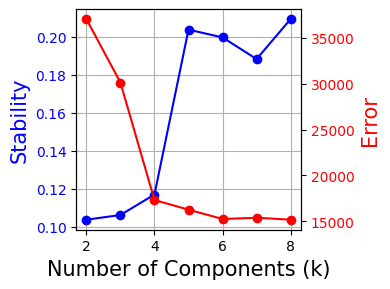

In [7]:
print(ds.adata.uns["kvals"])
fig = mosaicmpi.plot_stability_error(ds, figsize=[4, 3])

## 6. Program usages and gene programs

In [8]:
usages = ds.get_usages()
print("usage matrix (spots x programs):", usages.shape)
usages.head()

usage matrix (spots x programs): (150, 35)


2                 3                          4  \
                          1        2        1        2        3        1   
TAATGTCGGTTCATGG-1 0.788007 0.161480 0.506424 0.227811 0.205933 0.802229   
TCCTAAATTGGGAAGC-1 0.843265 0.167658 0.530330 0.249839 0.226721 0.900546   
TCCCTCCGAAATCGTT-1 0.886367 0.108396 0.643734 0.148147 0.178257 0.929857   
AAACTCGGTTCGCAAT-1 0.761805 0.279029 0.386605 0.414793 0.247551 0.801946   
CGCGGTAAGTCTAGCT-1 0.809352 0.295869 0.584226 0.362233 0.100506 0.893668   

                                                     5  ...        7           \
                          2        3        4        1  ...        6        7   
TAATGTCGGTTCATGG-1 0.071616 0.068343 0.009369 0.515155  ... 0.073337 0.013524   
TCCTAAATTGGGAAGC-1 0.073609 0.010258 0.009989 0.545226  ... 0.148000 0.000254   
TCCCTCCGAAATCGTT-1 0.003904 0.044994 0.000803 0.451609  ... 0.004950 0.000793   
AAACTCGGTTCGCAAT-1 0.229438 0.000126 0.008586 0.767500  ... 0.002951 0.000000   
CGCGGTAAGTCTAGCT-1 0.167589 0.009118 0.000083 0.468209  ... 0.000034 0.018903   

                          8                                               \
                          1        2        3        4        5        6   
TAATGTCGGTTCATGG-1 0.598760 0.155682 0.022505 0.013686 0.085028 0.060116   
TCCTAAATTGGGAAGC-1 0.713756 0.174447 0.011503 0.013975 0.001849 0.025228   
TCCCTCCGAAATCGTT-1 0.512202 0.342555 0.000016 0.006551 0.033567 0.049702   
AAACTCGGTTCGCAAT-1 0.876151 0.061846 0.075116 0.008957 0.000540 0.000454   
CGCGGTAAGTCTAGCT-1 0.453022 0.435623 0.166029 0.000508 0.001262 0.020041   

                                      
                          7        8  
TAATGTCGGTTCATGG-1 0.008657 0.024773  
TCCTAAATTGGGAAGC-1 0.004589 0.060439  
TCCCTCCGAAATCGTT-1 0.022111 0.000830  
AAACTCGGTTCGCAAT-1 0.002888 0.002149  
CGCGGTAAGTCTAGCT-1 0.000090 0.002488  

[5 rows x 35 columns]

In [9]:
programs = ds.get_programs(k=6, type="cnmf_gep_score")
print("k=6 gene programs (genes x programs):", programs.shape)
programs.iloc[:5]

k=6 gene programs (genes x programs): (300, 6)


program,1,2,3,4,5,6
RPL22,-0.000609,-0.002769,0.013101,-0.016498,0.019594,0.019840
ENO1,-0.000053,0.002610,-0.003240,-0.011335,0.044773,-0.011481
C1QA,0.000672,-0.010177,0.000264,0.001143,0.043399,-0.021670
RPL11,-0.000891,0.002628,0.011442,-0.017318,0.041520,-0.008259
SH3BGRL3,-0.000052,-0.004246,-0.001261,-0.011594,0.029998,0.023982


## 7. Usage heatmap

Any mosaicMPI visualization now reflects the OT-NMF programs.

Plotting HeatmapAnnotations


Z:\postdoc\projects\spOT-NMF\.venv\Lib\site-packages\PyComplexHeatmap\utils.py:569: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  cax.set_ylim([vmin, vmax])


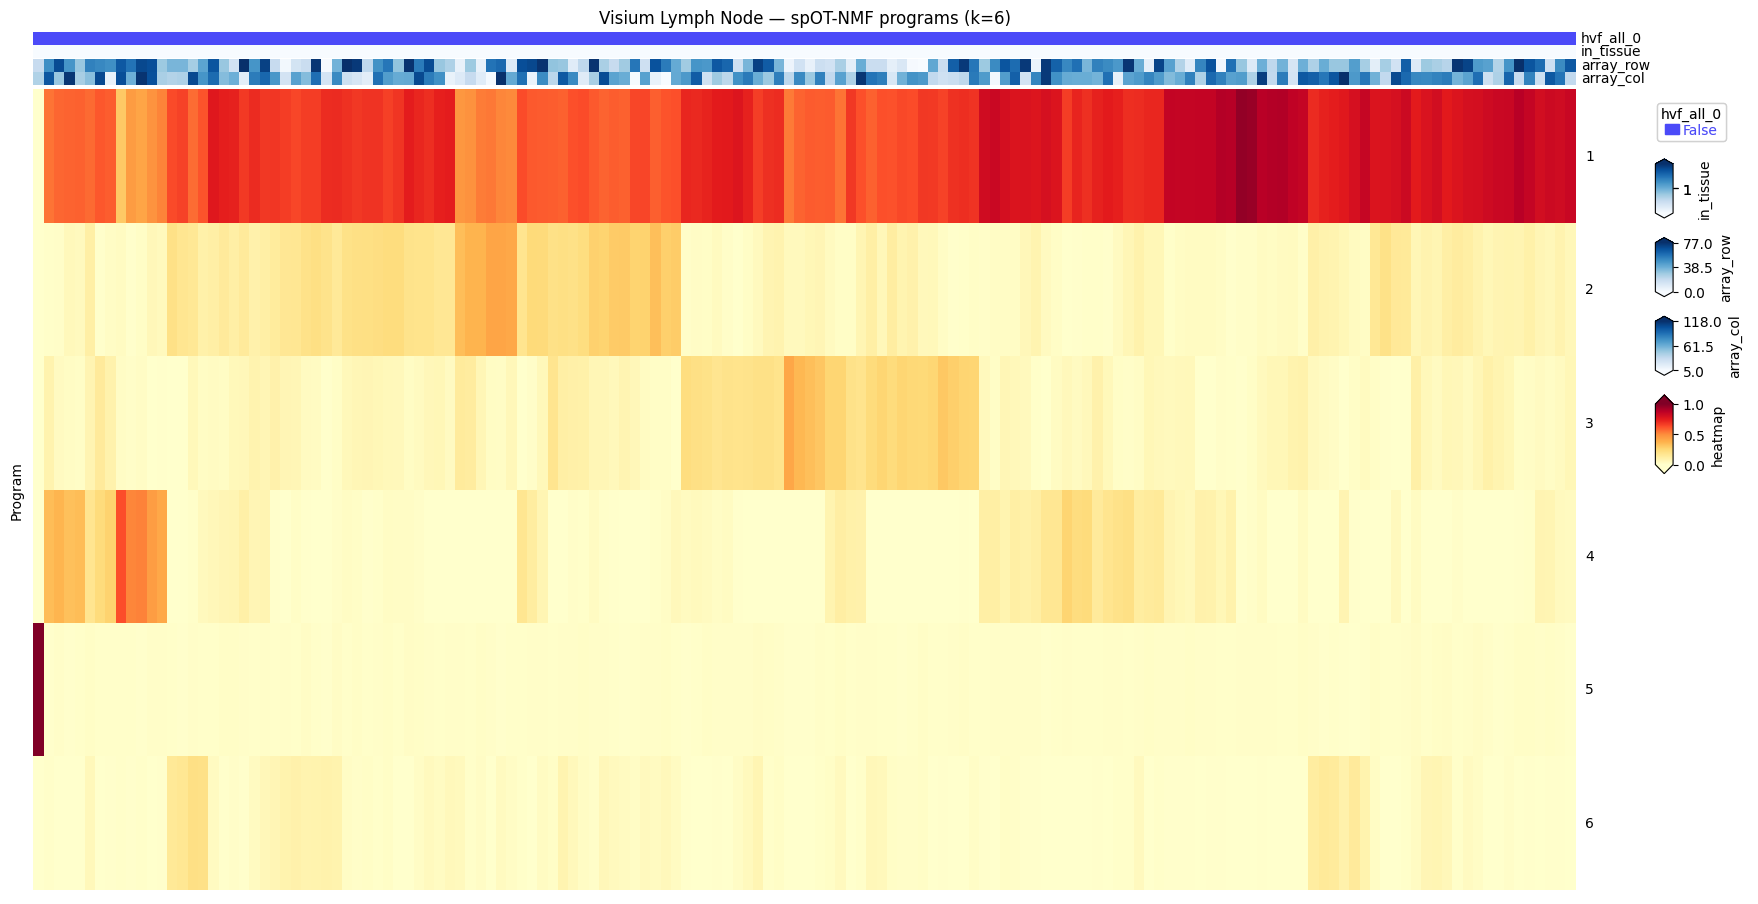

In [10]:
colors = mosaicmpi.Colors.from_dataset(ds, pastel_factor=0.4)
fig = mosaicmpi.plot_usage_heatmap(
    ds, k=6, colors=colors,
    title="Visium Lymph Node — spOT-NMF programs (k=6)")

## 8. Program network and community detection

This is what mosaicMPI is really built for: it correlates every program against
every other program (here across ranks 2–8 of one dataset; with several datasets
it does so across all of them), builds a graph of the most similar programs, and
detects **communities** of recurring programs. This works identically on the
OT-NMF programs produced above — nothing about the network step is cNMF-specific.

We use `corr_method="spearman"` so the correlation step needs no multiprocessing
(robust on any platform, including Windows notebooks). On Linux, or from a script
guarded by `if __name__ == "__main__":`, the default `"pearson"` uses all CPUs.

In [11]:
integration = mosaicmpi.Integration(
    datasets={"LymphNode": ds},
    k_subset=kvals,
    corr_method="spearman",       # avoids multiprocessing; default "pearson" is multi-CPU
    negative_corr_quantile=0.80,  # lower => keep more edges (this is a small demo network)
)
print("programs correlated:", integration.get_programs().shape[1],
      "| ranks:", integration.selected_k)

programs correlated: 35 | ranks: {'LymphNode': [2, 3, 4, 5, 6, 7, 8]}


In [12]:
network = mosaicmpi.Network(integration)
network.community_search(algorithm="greedy_modularity", resolution=1.0)
network.compute_layout(algorithm="spring", seed=7)  # deterministic, readable layout
print(f"program graph: {network.program_graph.number_of_nodes()} programs, "
      f"{network.program_graph.number_of_edges()} edges, "
      f"{network.n_communities} communities")

program graph: 35 programs, 80 edges, 7 communities


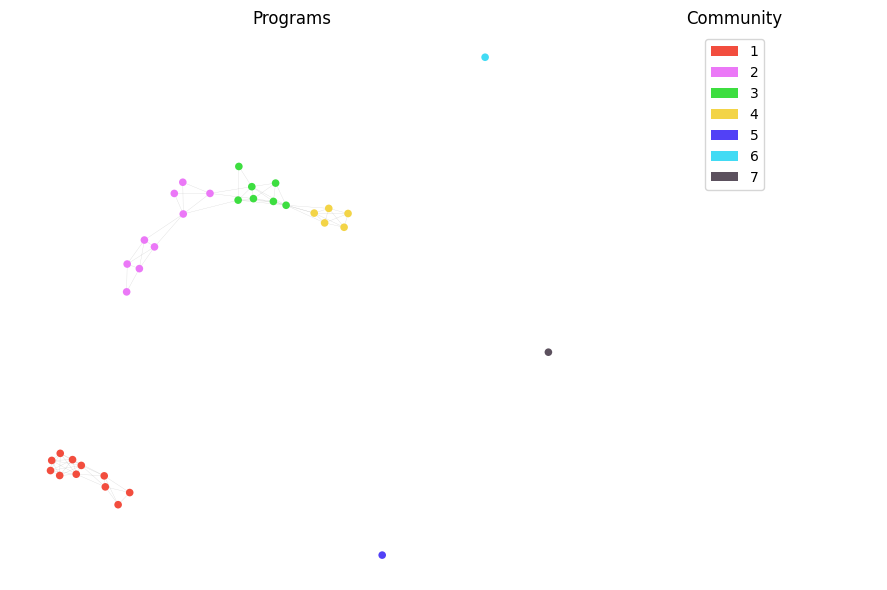

In [13]:
# Assign colors, including one per community, then draw the program network.
colors = mosaicmpi.Colors.from_integration(integration)
colors.add_missing_community_colors(network=network)

fig = mosaicmpi.plot_program_network_communities(network, colors)

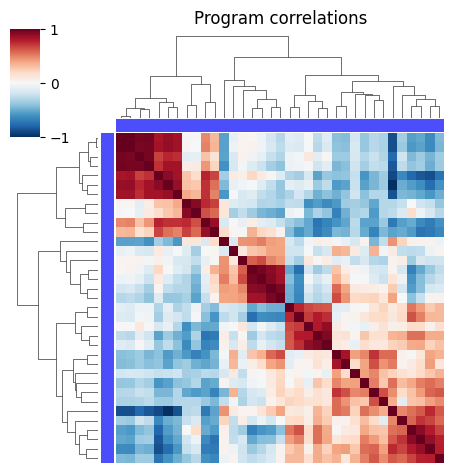

In [14]:
# The program-program correlation matrix underlying the network.
fig = mosaicmpi.plot_program_correlation_matrix(
    integration, colors, figsize=[6, 6], hide_program_labels=True)

Each node is one OT-NMF program (labelled `rank.program`); edges join highly
correlated programs and colors mark the detected communities. A community groups
programs that recur across ranks — the reproducible expression programs mosaicMPI
would carry forward (e.g. to compare or integrate multiple tissues/samples).

## Summary

- We ran the **mosaicMPI** consensus / rank-selection pipeline with **spOT-NMF**
  as the factorization engine, changing only `algorithm="spotnmf"`.
- The `spotnmf` backend is contributed by `spotnmf.mosaic` and registered through
  `mosaicmpi.factorization`; the built-in default remains `algorithm="cnmf"`.
- All downstream mosaicMPI features — stability/error curves, usage heatmaps,
  and the **program-correlation network with community detection** (and
  multi-dataset `Integration`) — work identically, because the on-disk result
  format is unchanged.

**To go back to standard cNMF**, drop the `algorithm`/`factorizer_params`
arguments (or set `algorithm="cnmf"`). **To scale up**, use the full dataset, a
wider `kvals` range, and `n_iter=100–200`; consider a GPU via
`factorizer_params={"device": "cuda"}`.